<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
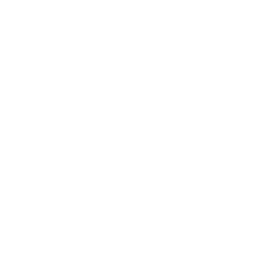
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Codering van bijwerkingen in klinische studies</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutica / Farmacovigilantie &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Datasets met bijwerkingen komen binnen met letterlijke MedDRA-geprefereerde
termen, maar regelgevende veiligheidstabellen zijn ingedeeld naar
systeemorgaanklasse (SOC). Dit voorbeeld bouwt een PROC FORMAT-waardeformaat
dat elke geprefereerde term koppelt aan zijn SOC, en gebruikt dat ene formaat
vervolgens om elke verdere tabellering aan te sturen: een PROC FREQ-kruistabel
van SOC per behandelarm, een uitsplitsing van SOC per ernstgraad, en een
samenvatting van ernstige bijwerkingen. Omdat de koppeling uitsluitend in het
formaat leeft, is het hercoderen van de studie naar een nieuwe MedDRA-versie
één formaatwijziging in plaats van het herschrijven van elk rapport. ODS OUTPUT
legt de SOC-frequenties vast als dataset voor verdere signaalbeoordeling.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------:|
| WORK.AE_RAW | Synthetische bijwerkingsgegevens met MedDRA-geprefereerde termen | 100 |
| WORK.RANDOMIZATION | Toewijzingen van proefpersonen aan behandelarmen | 100 |

De omgeving draait zonder licentie, dus elke gegenereerde tabel is
begrensd tot 100 waarnemingen. Het scenario is op die grens afgestemd: 100
bijwerkingen getrokken uit een MedDRA-panel van 12 termen, typisch voor een
oncologische studie.

---

In [1]:
/* --------------------------------------------------------
   Genereer synthetische dataset met bijwerkingen
   MedDRA-geprefereerde termen gekoppeld aan SOC-categorieën
   -------------------------------------------------------- */
GEGEVENS work.ae_raw;
    CALL streaminit(42);
    REEKS pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    REEKS pt_names[12] $30 _temporary_ ('Misselijkheid' 'Hoofdpijn' 'Braken' 'Diarree' 'Hoest' 'Vermoeidheid' 'Gewrichtspijn' 'Koorts' 'Buikpijn' 'Neutropenie' 'Koortsende neutropenie' 'Infusiegerelateerde reactie');
    REEKS sev_list[3] $10 _temporary_ ('LICHT' 'MATIG' 'ERNSTIG');
    DOE i = 1 TOT 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', SCHRIJVEN(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        aedecod = pt_names[pt_idx];
        sev_idx = int(rand('uniform') * 3) + 1;
        ALS pt_idx in (10, 11) DAN sev_idx = MAX(sev_idx, 2);
        aesev = sev_list[sev_idx];
        aeser = ifc(aesev = 'ERNSTIG' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        ALS aestdy > 365 DAN aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', SCHRIJVEN(int(rand('uniform') * 25) + 1, z3.));
        UITVOER;
    EINDE;
    VERWIJDEREN i pt_idx sev_idx;
UITVOEREN;


NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.28 seconds
  cpu   1.28 seconds


In [2]:
/* --------------------------------------------------------
   Genereer randomisatietabel van proefpersonen
   -------------------------------------------------------- */
GEGEVENS work.randomization;
    CALL streaminit(43);
    REEKS arms[3] $20 _temporary_ ('ONDERZOEKSMIDDEL' 'ACTIEVE_COMPARATOR' 'PLACEBO');
    DOE subject_id = 1 TOT 800;
        usubjid = cat('ONC-2025-', SCHRIJVEN(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        UITVOER;
    EINDE;
    VERWIJDEREN arm_idx;
    OPMAAK randomization_date date9.;
UITVOEREN;


NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---

                                  Ruwe frequentie geprefereerde term (niet gekoppeld)                                   

                                                   The FREQ Procedure

Geprefereerde term             Frequency    Percent
----------------------------------------------------
Diarree                               12     12.00
Hoofdpijn                             12     12.00
Koorts                                11     11.00
Vermoeidheid                          11     11.00
Gewrichtspijn                         10     10.00
Misselijkheid                         10     10.00
Infusiegerelateerde reactie            8      8.00
Hoest                                  7      7.00
Buikpijn                               5      5.00
Koortsende neutropenie                 5      5.00
Neutropenie                            5      5.00
Braken                                 4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


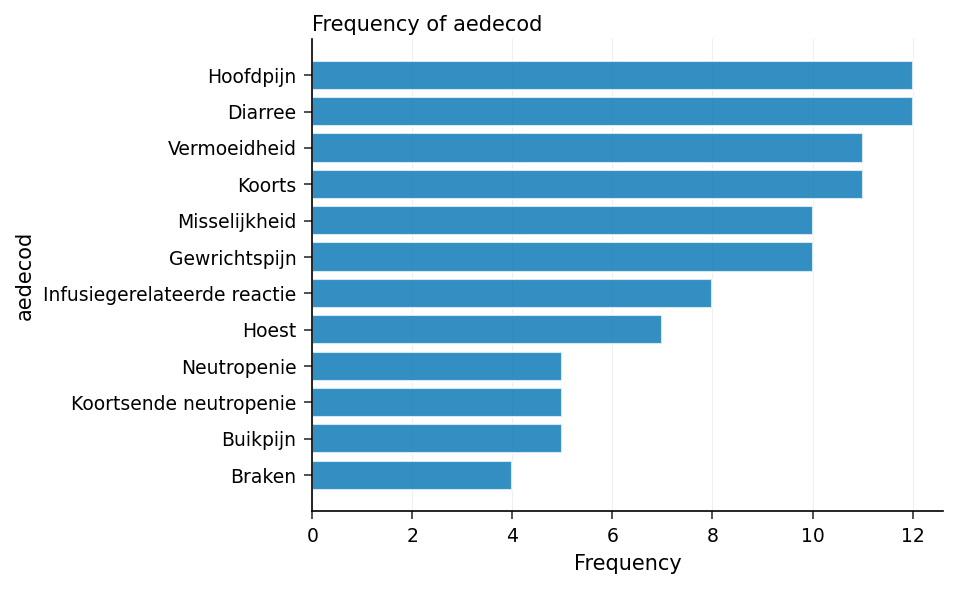

In [3]:
/* --------------------------------------------------------
   Basisfrequentie van geprefereerde term vóór SOC-koppeling
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.ae_raw ORDER=FREQUENTIES;
    TABLES aedecod / nocum;
    label aedecod='Geprefereerde term';
    TITEL 'Ruwe frequentie geprefereerde term (niet gekoppeld)';
UITVOEREN;

---

                                  Ruwe frequentie geprefereerde term (niet gekoppeld)                                   




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


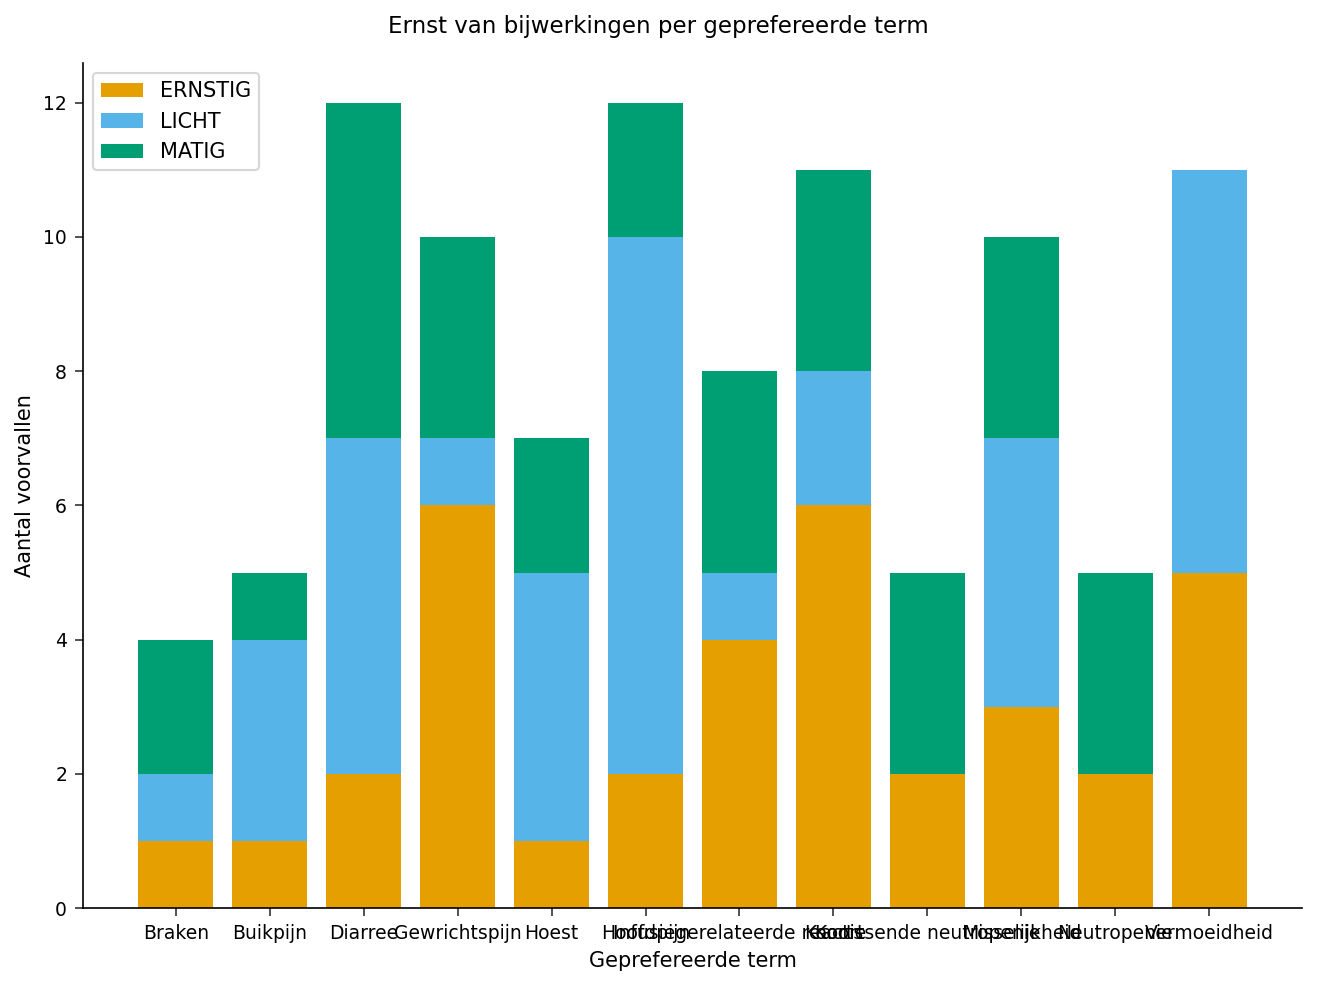

In [4]:
/* --------------------------------------------------------
   Verdeling van ernst van bijwerkingen per geprefereerde term
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    label aedecod='Geprefereerde term' aesev='Ernst';
    XAXIS label='Geprefereerde term' fitpolicy=ROTATE;
    YAXIS label='Aantal voorvallen';
    TITEL 'Ernst van bijwerkingen per geprefereerde term';
UITVOEREN;

---

In [5]:
/* --------------------------------------------------------
   Definieer het waardeformaat MedDRA-geprefereerde term ->
   systeemorgaanklasse. Het formaat is gesleuteld op de tekst
   van de geprefereerde term, zodat één PUT()-aanroep elk
   bijwerkingsrecord aan zijn SOC koppelt.
   -------------------------------------------------------- */
PROCEDURE OPMAAK;
    VALUE $pt_to_soc
        'Misselijkheid'               = 'Maagdarmstelselaandoeningen'
        'Braken'                      = 'Maagdarmstelselaandoeningen'
        'Diarree'                     = 'Maagdarmstelselaandoeningen'
        'Buikpijn'                    = 'Maagdarmstelselaandoeningen'
        'Hoofdpijn'                   = 'Zenuwstelselaandoeningen'
        'Vermoeidheid'                = 'Algemene aandoeningen'
        'Koorts'                      = 'Algemene aandoeningen'
        'Hoest'                       = 'Ademhalingsstelselaandoeningen'
        'Gewrichtspijn'               = 'Skeletspierstelselaandoeningen'
        'Neutropenie'                 = 'Bloed- en lymfestelselaandoeningen'
        'Koortsende neutropenie'      = 'Bloed- en lymfestelselaandoeningen'
        'Infusiegerelateerde reactie' = 'Immuunsysteemaandoeningen'
        OTHER                         = 'Ongecodeerd'
    ;
    VALUE $sev_rank
        'LICHT'    = '1-Licht'
        'MATIG'    = '2-Matig'
        'ERNSTIG'  = '3-Ernstig'
        OTHER      = '9-Onbekend'
    ;
    VALUE $serious_fmt
        'Y' = 'Ernstig'
        'N' = 'Niet-ernstig'
    ;
UITVOEREN;


NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Voeg bijwerkingsrecords samen met de behandelarm en pas
   dan het SOC-formaat toe. PUT(aedecod, $pt_to_soc.) is de
   enige koppelstap die nodig is; ernst en ernstigheid worden
   op dezelfde manier gecodeerd.
   -------------------------------------------------------- */
PROCEDURE SORTEREN GEGEVENS=work.ae_raw; VOLGENS usubjid; UITVOEREN;
PROCEDURE SORTEREN GEGEVENS=work.randomization; VOLGENS usubjid; UITVOEREN;

GEGEVENS work.ae_coded;
    SAMENVOEGEN work.ae_raw (in=a)
          work.randomization (in=b BEWAREN=usubjid treatment_arm);
    VOLGENS usubjid;
    ALS a;
    soc_class     = SCHRIJVEN(aedecod, $pt_to_soc.);
    severity_rank = SCHRIJVEN(aesev,   $sev_rank.);
    serious_flag  = SCHRIJVEN(aeser,   $serious_fmt.);
UITVOEREN;


NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


                           Incidentie van bijwerkingen per systeemorgaanklasse en behandelarm                           

                                                   The FREQ Procedure

Table of Systeemorgaanklasse (SOC) by Behandelarm

Systeemorgaanklasse (SOC)          |ACTIEVE_COMPARATOR |  ONDERZOEKSMIDDEL |           PLACEBO |              Total
-----------------------------------+-------------------+-------------------+-------------------+-------------------
Algemene aandoeningen              |                 1 |                 1 |                 3 |                  5
-----------------------------------+-------------------+-------------------+-------------------+-------------------
Bloed- en lymfestelselaandoeningen |                 0 |                 1 |                 1 |                  2
-----------------------------------+-------------------+-------------------+-------------------+-------------------
Immuunsysteemaandoeningen          |                 0 |    


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


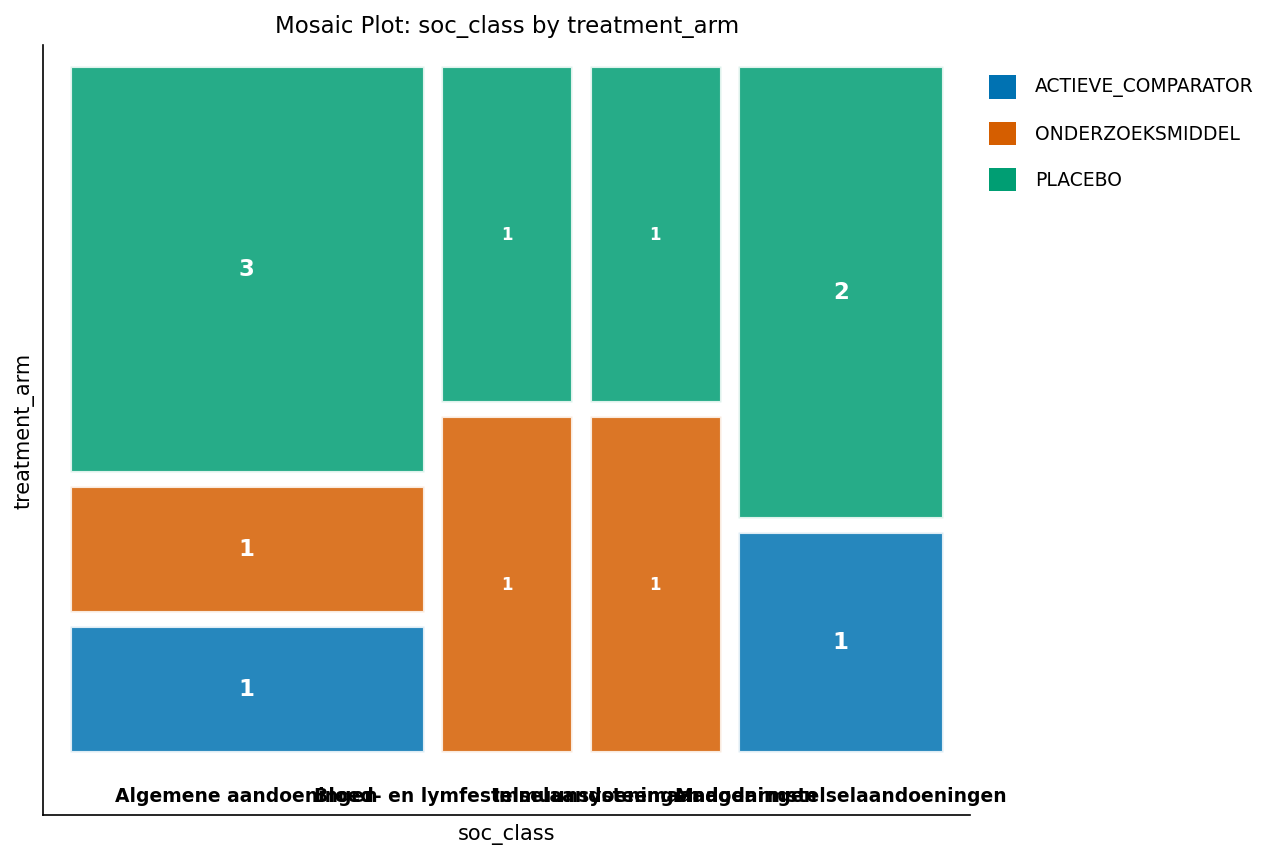

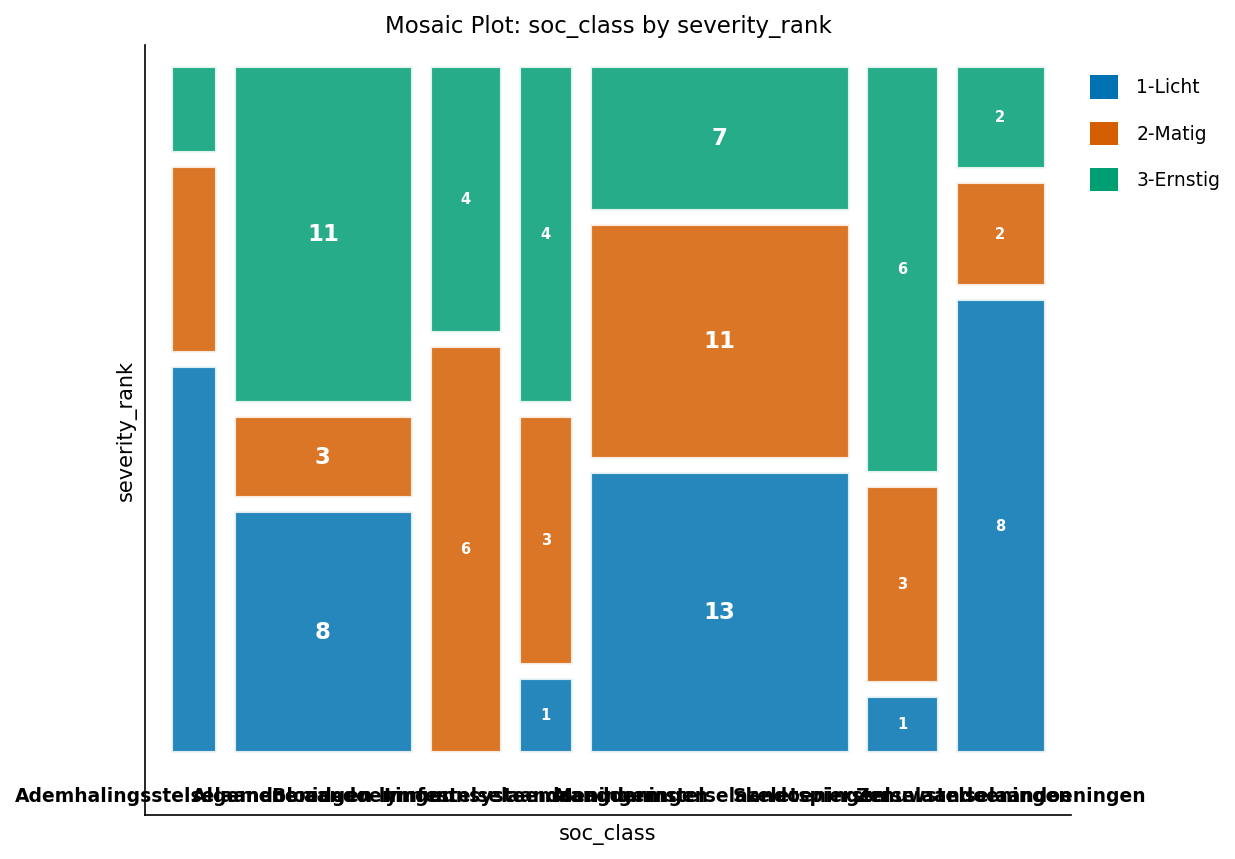

In [7]:
/* --------------------------------------------------------
   SOC-frequentie per behandelarm
   ODS OUTPUT legt resultaten vast voor signaaldetectie
   -------------------------------------------------------- */
ODS UITVOER onewayfreqs=work.soc_freq_table;

PROCEDURE FREQUENTIES GEGEVENS=work.ae_coded ORDER=FREQUENTIES;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    label soc_class='Systeemorgaanklasse (SOC)' treatment_arm='Behandelarm' severity_rank='Ernstgraad';
    TITEL 'Incidentie van bijwerkingen per systeemorgaanklasse en behandelarm';
UITVOEREN;

ODS UITVOER CLOSE;

                                      Ernstige bijwerkingen per SOC en behandelarm                                      

                                                   The FREQ Procedure

Table of Systeemorgaanklasse (SOC) by Behandelarm

Systeemorgaanklasse (SOC) |ACTIEVE_COMPARATOR |  ONDERZOEKSMIDDEL |           PLACEBO |              Total
--------------------------+-------------------+-------------------+-------------------+-------------------
Algemene aandoeningen     |                 1 |                 1 |                 1 |                  3
--------------------------+-------------------+-------------------+-------------------+-------------------
Immuunsysteemaandoeningen |                 0 |                 0 |                 1 |                  1
--------------------------+-------------------+-------------------+-------------------+-------------------
Total                     |                 1 |                 1 |                 2 |                  4




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


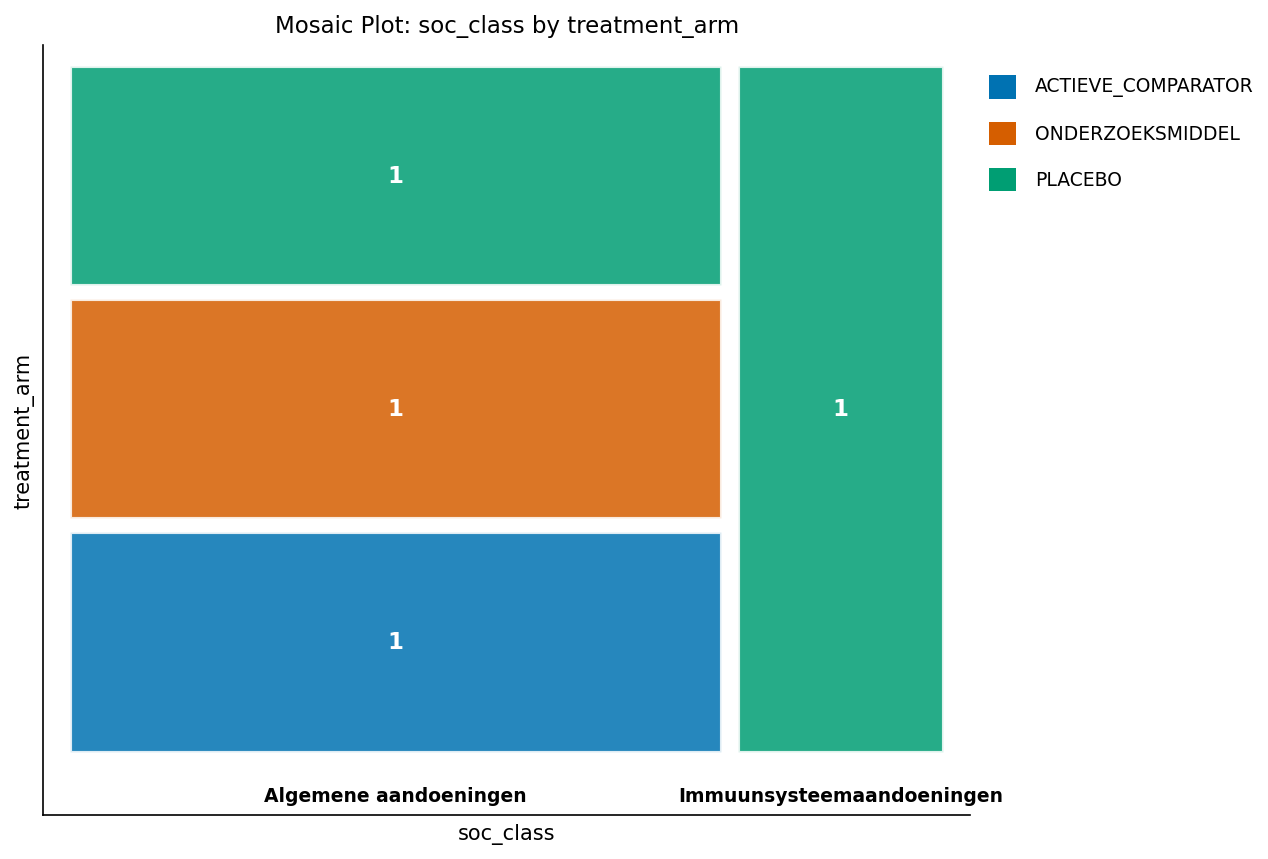

In [8]:
/* --------------------------------------------------------
   Samenvatting van ernstige bijwerkingen per SOC voor
   veiligheidsnarratief
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.ae_coded;
    WAAR aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    label soc_class='Systeemorgaanklasse (SOC)' treatment_arm='Behandelarm';
    TITEL 'Ernstige bijwerkingen per SOC en behandelarm';
UITVOEREN;

---

### Interpretatie

Eén waardeformaat `$pt_to_soc` codeerde alle 100 bijwerkingen uit 12
letterlijke MedDRA-geprefereerde termen naar 7 systeemorgaanklassen, en dat ene
formaat stuurde elke onderstaande tabel aan zonder de gegevens te hercoderen.

Per SOC en ernstgraad is **Maagdarmstelselaandoeningen** de meest voorkomende
klasse met 31 van de 100 voorvallen (13 licht, 11 matig, 7 ernstig), gevolgd
door **Algemene aandoeningen** met 22 voorvallen. De overige klassen zijn
kleiner: Zenuwstelselaandoeningen (12), Bloed- en lymfestelselaandoeningen
(10), Skeletspierstelselaandoeningen (10), Immuunsysteemaandoeningen (8), en
Ademhalingsstelselaandoeningen (7). Over alle voorvallen is de ernstverdeling
35 licht, 30 matig en 35 ernstig.

Slechts 4 voorvallen werden als ernstig gemarkeerd (`aeser='Y'`): 3 in
Algemene aandoeningen (één per arm) en 1 in Immuunsysteemaandoeningen
(placebo). De kruistabel van SOC per behandelarm is opgebouwd uit de 12
voorvallen waarvan de proefpersoon overeenkwam met een randomisatierecord, dus
de aantallen per arm zijn illustratief in plaats van onderbouwd voor een
vergelijking tussen armen.

De kernboodschap is het FORMAT-mechanisme, niet de synthetische getallen:
omdat de koppeling van geprefereerde term naar SOC uitsluitend in PROC FORMAT
leeft, hercodeert dezelfde aanroep `PUT(aedecod, $pt_to_soc.)` de hele
dataset, en betekent overstappen naar een nieuwe MedDRA-woordenboekversie het
bewerken van één formaat in plaats van elk rapport. ODS OUTPUT legde de
SOC-frequenties vast als `work.soc_freq_table` voor verdere
signaalbeoordeling.

---

In [9]:
/* --------------------------------------------------------
   Exporteer de SOC-gecodeerde AE-dataset voor
   veiligheidssignaalbeoordeling. Het ene $pt_to_soc-formaat
   heeft soc_class gevuld, dus het geëxporteerde bestand is
   gereed voor verdere analyse op SOC-niveau.
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
UITVOEREN;


NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>